In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Exploración inicial**


In [ ]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nNulos por columna:")
print(df.isna().sum())

print("\nDuplicados:", df.duplicated().sum())

print("\nDescribe numérico:")
display(df.describe())

Shape: (891, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **Limpieza y Transformación**

In [ ]:
#quitamos columnas que no tomaremos en cuenta en el estudio por contener demasiados nulos o por ser poco concluyentes.
df_clean = df.copy()
cols_to_drop = ['Cabin','Embarked', 'Name', 'Ticket', 'PassengerId']
df_clean = df_clean.drop(columns=cols_to_drop)

In [ ]:
# rellenamos datos vacios de "age" con la edad media para transformar la columna
# en una que nos sirva para este estudio.
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())


In [ ]:
#cambiamos tipo de dato "objeto" a booleano la columna "Sex"
df_clean = pd.get_dummies(df_clean, columns=['Sex'], drop_first=True)

In [ ]:
print("Shape:", df_clean.shape)
print("\nInfo:")
print(df_clean.info())

print("\nNulos por columna:")
print(df_clean.isna().sum())

print("\nDescribe numérico:")
display(df_clean.describe())

Shape: (891, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Sex_male  891 non-null    bool   
dtypes: bool(1), float64(2), int64(4)
memory usage: 42.8 KB
None

Nulos por columna:
Survived    0
Pclass      0
Age         0
SibSp       0
Parch       0
Fare        0
Sex_male    0
dtype: int64

Describe numérico:


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


en el grafico se puede apreciar el promedio de rango etario que sobrevivio al titanic,

# **Presentacion del problema**

En este proyecto se busca responder a la pregunta:

“¿Qué modelo de Machine Learning predice mejor la probabilidad de supervivencia de los pasajeros del Titanic?”

Para ello, se comparan dos enfoques de clasificación: Regresión Logística, como modelo base clásico y fácil de interpretar, y Árbol de Decisión, como modelo basado en reglas que permite identificar patrones no lineales.

#**Train/Test Regresión Logistica**
La Regresión Logística es un modelo estadístico usado para clasificación binaria.
En vez de predecir un número continuo (como la lineal), predice la probabilidad de pertenecer a una clase (ej: sobrevivir = 1 o no = 0).

Ejemplo Titanic

Si la logística predice
𝑝 = 0.8
interpretamos: Este pasajero tiene 80% de probabilidad de sobrevivir.

Luego ponemos un umbral (generalmente 0.5):

Si 𝑝 > 0.5 ⇒ predice 1 (sobrevive).

Si 𝑝 ≤ 0.5 ⇒ predice 0 (no sobrevive).


/tmp/ipython-input-3145290147.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean()


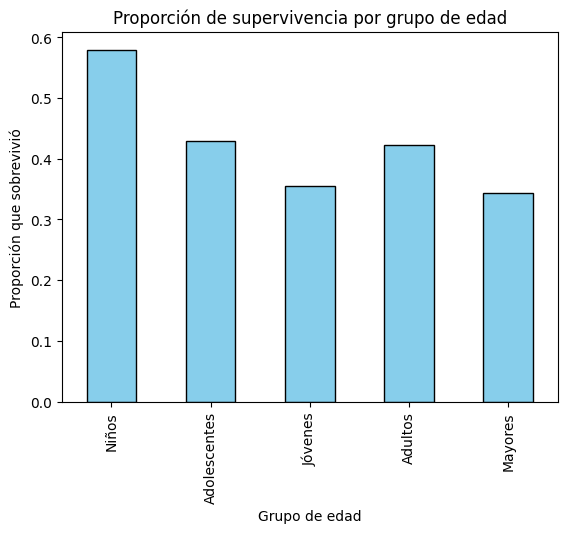

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear rangos de edad
bins = [0, 12, 18, 30, 50, 80]
labels = ['Niños','Adolescentes','Jóvenes','Adultos','Mayores']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Calcular proporción de supervivencia por grupo de edad
age_survival = df.groupby('AgeGroup')['Survived'].mean()

# Gráfico
age_survival.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Proporción de supervivencia por grupo de edad")
plt.ylabel("Proporción que sobrevivió")
plt.xlabel("Grupo de edad")
plt.show()

En el grafico podemos apreciar que el rango etario de niños presenta el mayor indice de supervivencia entre los grupos estudiadios.

Esto toma sentido mas adelante cuando veamos que el arbol de decisiones toma en cuenta esta caracteristica del DataFrame.




In [ ]:
from sklearn.model_selection import train_test_split

# Variables
y = df_clean['Survived']
X = df_clean.drop(columns=['Survived'])

# Dividir en 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño Train:", X_train.shape, "Tamaño Test:", X_test.shape)

Tamaño Train: (712, 6) Tamaño Test: (179, 6)


Entrenamos dos modelos:

Regresión Logística → Modelo estadístico clásico de clasificación.

Árbol de Decisión → Modelo basado en reglas que se ramifican (if/else).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Modelo Regresión Logistica
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)

# Predicciones de la IA
y_pred_logit = logit.predict(X_test)

# Métricas
print("=== Regresión Logística ===")
print("Accuracy:", accuracy_score(y_test, y_pred_logit))
print("Precision:", precision_score(y_test, y_pred_logit))
print("Recall:", recall_score(y_test, y_pred_logit))
print("F1:", f1_score(y_test, y_pred_logit))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_logit))
print("\nReporte clasificación:\n", classification_report(y_test, y_pred_logit))

=== Regresión Logística ===
Accuracy: 0.8044692737430168
Precision: 0.765625
Recall: 0.7101449275362319
F1: 0.7368421052631579

Matriz de confusión:
 [[95 15]
 [20 49]]

Reporte clasificación:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



=== Árbol de Decisión ===
Accuracy: 0.8100558659217877
Precision: 0.8181818181818182
Recall: 0.6521739130434783
F1: 0.7258064516129032

Matriz de confusión:
 [[100  10]
 [ 24  45]]

Reporte clasificación:
               precision    recall  f1-score   support

           0       0.81      0.91      0.85       110
           1       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



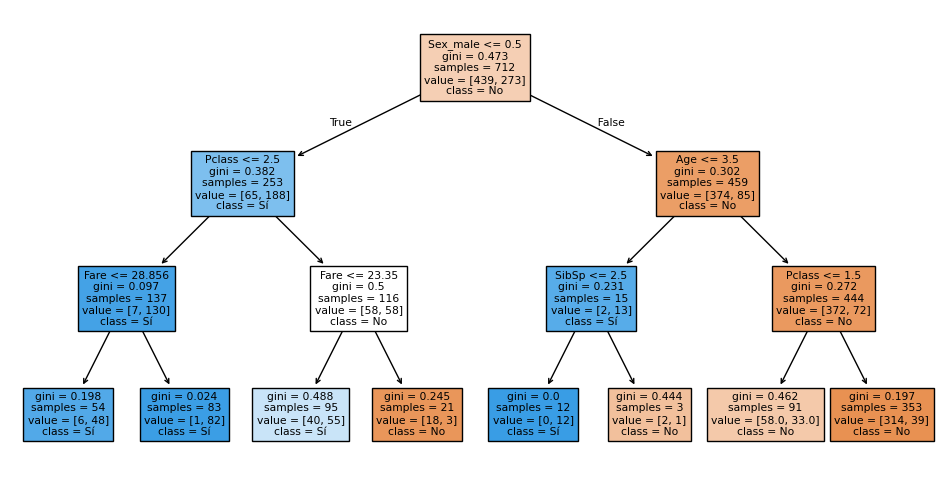

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Modelo
tree = DecisionTreeClassifier(max_depth=3, random_state=42)  # limitamos profundidad para interpretabilidad
tree.fit(X_train, y_train)

# Predicciones
y_pred_tree = tree.predict(X_test)

# Métricas
print("=== Árbol de Decisión ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1:", f1_score(y_test, y_pred_tree))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_tree))
print("\nReporte clasificación:\n", classification_report(y_test, y_pred_tree))

# Visualizar árbol
plt.figure(figsize=(12,6))
plot_tree(tree, feature_names=X.columns, class_names=['No', 'Sí'], filled=True)
plt.show()

# **Explicacion arbol de desiciones**

**Primer nodo (la raíz)**

Sex_male <= 0.5

0.5 significa que el modelo codificó "mujer = 0" y "hombre = 1".

Si es ≤ 0.5 → mujer, va a la izquierda.

Si es > 0.5 → hombre, va a la derecha.

Según el dataset, el sexo es el factor más fuerte: las mujeres tenían más probabilidad de sobrevivir.

**Rama derecha (hombres)**

Se pregunta primero por la edad (Age <= 3.5).

Los pocos niños pequeños (≤ 3 años) tenían más chances de sobrevivir (sí).

Luego entra SibSp (número de hermanos/esposas a bordo) → con muy pocos datos pero también puede predecir supervivencia.

La mayoría de los hombres terminan en nodos naranja (predicción = "No").

In [ ]:
import seaborn as sns

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No sobrevivió", "Sobrevivió"],
                yticklabels=["No sobrevivió", "Sobrevivió"])
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

# **Explicación de la matriz de confusión**
**Regresión Logistica**

TN = 90 → El modelo acertó 90 pasajeros que no sobrevivieron.

FP = 15 → El modelo “creyó” que 15 sobrevivieron, pero en realidad no.

FN = 20 → El modelo dijo que 20 no sobrevivieron, pero sí lo hicieron (¡error grave en Titanic!).

TP = 49 → El modelo acertó 49 sobrevivientes.

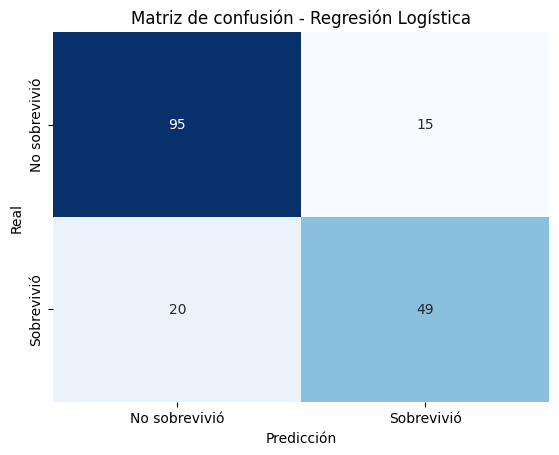

In [ ]:
plot_conf_matrix(y_test, y_pred_logit, "Matriz de confusión - Regresión Logística")

**Arbol de desiciones**

TP = 35 → sobrevivientes detectados.

TN = 104 → “no sobrevivió” bien predicho.

FN = 34 → sobrevivientes que clasificó mal como muertos (problema en recall).

FP = 6 → personas que no sobrevivieron, pero el modelo pensó que sí (problema en precisión).

En este caso, vemos que el modelo prefiere disminuir los Falsos Posivos (FP) dado que los casos en que la IA interpreta que la persona sobrevivio pero la realidad es que no, son solo 6, en comparación a los casos de las personas que fueron confundidas como muertas cuando en realidad si sobrevivieron (que son 20).

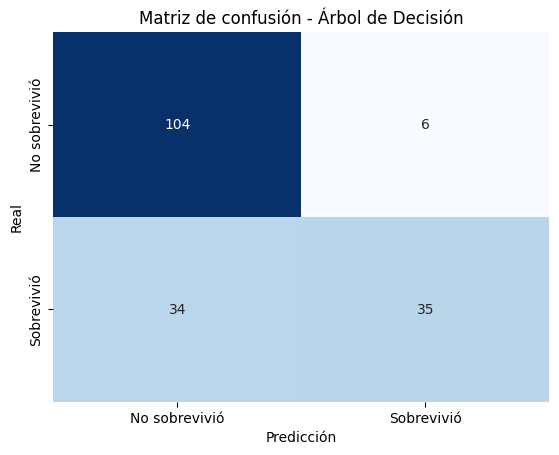

In [ ]:
plot_conf_matrix(y_test, y_pred_tree, "Matriz de confusión - Árbol de Decisión")

# **Conclusiones**

**Comparacion de ambos modelos:**


1.   si comparamos los TP (verdareros positivos) de ambos modelos, podemos ver que el arbol de decisiones obtiene una mayor cantidad de aciertos al momento de predecir a alguien que no sobrevivio, si agregamos a este analisis los FP(falso positivo) podemos tambien ver una diferencia entre los modelos en comparación, lo cual apunta a que el modelo de arbol de decisiones es mejor al momento de predecir a un pasajero que no sobrevive.

2.  Si comparamos los FN (falsos negativos) de ambos modelos, veremos que la regresion logistica se equivoca en menos casos que el arbol de desiciones, ademas obtiene un numero de aciertos mayor en los TN (verdaderos negativos) en comparacion al modelo de arbol de desiciones.

3. En el caso del modelo arbol de desiciones podemos apreciar que tanto los FN (falsos negativos) como los TN (verdaderos negativos) tienen un numero de casos parecidos, lo que apunta a que el modelo no es concluyente ni confiable al momento de predecir a los supervivientes.

4. En cambio, el modelo de regresión logistica tiene un menor numero de casos tanto de FN (falso negativo) como un mayor numero de aciertos en TN(verdadero negativo), lo que indica que el modelo tiende a predecir mejor los casos de superivientes que el modelo de arbol de desiciones.

5. En el arbol de confusion, la primera pregunta que se ahce el modelo es si es su sexo es hombre o mujer, en caso de ser mujer se logra ver que la mayoria de los nodos pertenecen a los casos que si sobrevivieron, lo cual indica que su indice de supervivencia es la mayor entre ambos sexos. tambien en caso de la rama del sexo masculino, el modelo se pregunta si la edad del caso es menor a 3,5 años, lo cual indica que los niños fue la edad etaria con mayor indice de superviviente en esto casos.

Conclución: el modelo de regresión logistica es mas consistente en predecir ambos casos de manera acertada, pero el arbol de desiciones tiene una mayor presicion al momento de predecir a los que no sobrevivieron.

Recomendaciones: Si se quiere aumentar la precision de ambos modelos, aconsejamos ocupar un Dataset que contenga un mayor datos de "cabin", de esta forma tambien podemos agregar a al modelo la posicion de cada persona en el titanic.

dato curioso: con este modelo podemos demostrar que la frase "mujeres y niños primero" es verdadera en el caso del titanic.